# Convolutional Neural Network II: Classification d'objets Recyclables ou Non

In [ ]:
# !rm -rf ./DATASET
!rm -rf ./dataset

In [ ]:
from google.colab import drive
drive.mount('/gdrive')

Mounted at /gdrive


In [ ]:
!ls '/gdrive/MyDrive/data'

births.csv	   exemple.txt				     WASTE.zip
births_github.csv  Synthetic_Financial_datasets_log.csv.zip
decades.csv	   WASTE_COURT.zip


In [ ]:
fichier_archive = 'gdrive/MyDrive/data/WASTE.zip'
# Origine du dataset: https://www.kaggle.com/datasets/techsash/waste-classification-data?resource=download

!unzip -o '/{fichier_archive}' -d './' # <= Activer pour vraiment importer

Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.
  inflating: ./WASTE/TRAIN/R/R_5499.jpg  
  inflating: ./WASTE/TRAIN/R/R_55.jpg  
  inflating: ./WASTE/TRAIN/R/R_550.jpg  
  inflating: ./WASTE/TRAIN/R/R_5500.jpg  
  inflating: ./WASTE/TRAIN/R/R_5501.jpg  
  inflating: ./WASTE/TRAIN/R/R_5502.jpg  
  inflating: ./WASTE/TRAIN/R/R_5503.jpg  
  inflating: ./WASTE/TRAIN/R/R_5504.jpg  
  inflating: ./WASTE/TRAIN/R/R_5505.jpg  
  inflating: ./WASTE/TRAIN/R/R_5506.jpg  
  inflating: ./WASTE/TRAIN/R/R_5507.jpg  
  inflating: ./WASTE/TRAIN/R/R_5508.jpg  
  inflating: ./WASTE/TRAIN/R/R_5509.jpg  
  inflating: ./WASTE/TRAIN/R/R_551.jpg  
  inflating: ./WASTE/TRAIN/R/R_5510.jpg  
  inflating: ./WASTE/TRAIN/R/R_5511.jpg  
  inflating: ./WASTE/TRAIN/R/R_5512.jpg  
  inflating: ./WASTE/TRAIN/R/R_5513.jpg  
  inflating: ./WASTE/TRAIN/R/R_5514.jpg  
  inflating: ./WASTE/TRAIN/R/R_5515.jpg  
  inflating: ./WASTE/TRAIN/R/R_5516.jpg  
  inflating: ./WASTE/TRAIN/R/R_5517.jpg  
  

In [ ]:
!rm -rf ./dataset

In [ ]:
import os

In [ ]:
data_dir = "WASTE"

In [ ]:
train_dir = os.path.join(data_dir, "TRAIN")
test_dir = os.path.join(data_dir, "TEST")

In [ ]:
os.listdir(train_dir)

['R', 'O']

In [ ]:
train_r_dir = os.path.join(train_dir, "R")
train_o_dir = os.path.join(train_dir, "O")

In [ ]:
len(os.listdir(train_r_dir)), len(os.listdir(train_o_dir))

(9999, 12565)

In [ ]:
from tabulate import tabulate
import os

train_r_count = len(os.listdir(train_r_dir))
train_o_count = len(os.listdir(train_o_dir))
test_r_count = len(os.listdir(os.path.join(test_dir, "R")))
test_o_count = len(os.listdir(os.path.join(test_dir, "O")))

total_r = train_r_count + test_r_count
total_o = train_o_count + test_o_count
total_train = train_r_count + train_o_count
total_test = test_r_count + test_o_count
grand_total = total_train + total_test


data = [
    ["Recyclable (R)", train_r_count, test_r_count, total_r],
    ["Organic (O)", train_o_count, test_o_count, total_o],
    ["Cumulative", total_train, total_test, grand_total]
]

headers = ["Category", "Train", "Test", "Cumulative"]

print(tabulate(data, headers=headers, tablefmt="grid"))

+----------------+---------+--------+--------------+
| Category       |   Train |   Test |   Cumulative |
+================+=========+========+==============+
| Recyclable (R) |    9999 |   1112 |        11111 |
+----------------+---------+--------+--------------+
| Organic (O)    |   12565 |   1401 |        13966 |
+----------------+---------+--------+--------------+
| Cumulative     |   22564 |   2513 |        25077 |
+----------------+---------+--------+--------------+


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

In [ ]:
r_index = 568
o_index = 1596

recyclable_imgs = [os.path.join(train_r_dir, filename) for filename in os.listdir(train_r_dir)]
organic_imgs = [os.path.join(train_o_dir, filename) for filename in os.listdir(train_o_dir)]

img_r = mpimg.imread(recyclable_imgs[r_index])
img_o = mpimg.imread(organic_imgs[o_index])

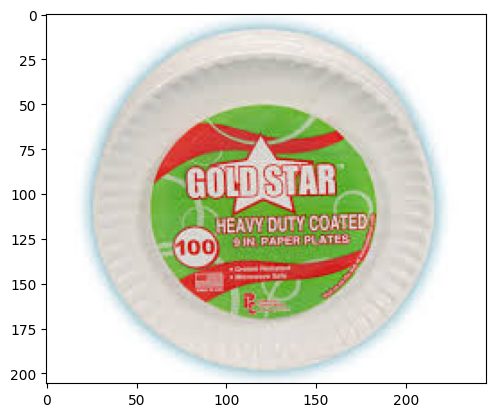

In [ ]:
plt.imshow(img_r)

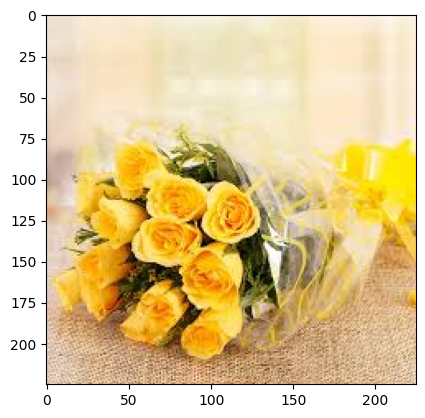

In [ ]:
plt.imshow(img_o)

In [ ]:
# training_labels.shape # Inconnu ! → Solution = ImageDataGenerator

## ImageDataGenerator

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
train_data_generator = ImageDataGenerator(rescale=1/255.0)
test_data_generator = ImageDataGenerator(rescale=1/255.0)

In [ ]:
train_generator = train_data_generator.flow_from_directory(
    directory = train_dir,
    target_size = (224, 224),
    batch_size=32,
    class_mode="binary"
)

test_generator = test_data_generator.flow_from_directory(
    directory = test_dir,
    target_size = (224, 224),
    batch_size=32,
    class_mode="binary"
)

Found 22564 images belonging to 2 classes.
Found 2513 images belonging to 2 classes.


In [ ]:
batch_images, batch_labels = next(iter(train_generator))

In [ ]:
batch_images.shape

(32, 224, 224, 3)

In [ ]:
batch_labels.shape, batch_labels

((32,),
 array([0., 1., 1., 1., 1., 1., 0., 0., 1., 1., 0., 0., 1., 1., 1., 1., 1.,
        0., 0., 0., 0., 0., 1., 0., 1., 0., 1., 1., 1., 0., 1., 0.],
       dtype=float32))

In [ ]:
train_generator.class_indices

{'O': 0, 'R': 1}

In [ ]:
labels = list(train_generator.class_indices.keys())
labels

['O', 'R']

Image # 30 - Label: R


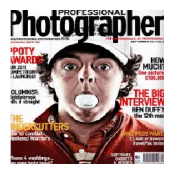

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt

index = 30

print(f"Image # {index} - Label:", labels[int(batch_labels[index])])

# Create a figure and axes with a size that makes the image appear around 112x112
# The exact figsize might need some trial and error depending on your display
plt.figure(figsize=(2, 2)) # Adjust figsize as needed to get the desired visual size

# Display the original size image from the batch
img_to_display = batch_images[index]
plt.imshow(img_to_display)

# Turn off the axis
plt.axis('off')

plt.show()

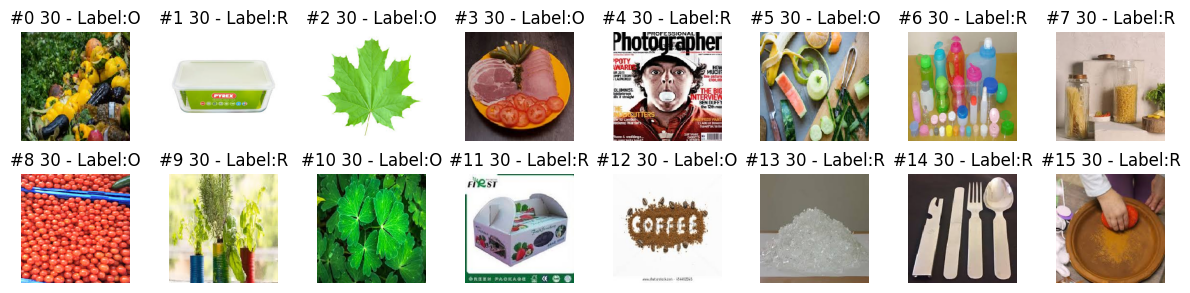

In [ ]:
import random
import tensorflow as tf
import matplotlib.pyplot as plt

nb_imgs = 16 # Max 32 car batch en contient que 32
random_indices = random.sample(range(0, batch_images.shape[0]), nb_imgs) # Get 10 random indices from the batch (content 32)

# Determine the number of rows and columns for the subplots
n_images = len(random_indices)
n_cols = 8 # You can adjust the number of columns as needed
n_rows = (n_images + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols * 1.5, n_rows * 1.5)) # Adjust figure size for smaller visual display

for i, img_index in enumerate(random_indices):
  plt.subplot(n_rows, n_cols, i + 1)
  plt.imshow(batch_images[img_index]) # Display the original size image from the batch

  plt.title(labels[int(batch_labels[img_index])])
  plt.title(f"#{i} {index} - Label:"+labels[int(batch_labels[img_index])])
  plt.axis('off')

# Adjust subplot spacing
plt.tight_layout()
plt.subplots_adjust(wspace=.1, hspace=.3) # Adjust wspace (width space) and hspace (height space) as needed


plt.show()

## Modeling

In [ ]:
import tensorflow as tf

In [ ]:
model = tf.keras.models.Sequential([

    #Extraction de caractéristiques
    tf.keras.layers.Conv2D(filters=32, kernel_size=(3, 3), padding="same", activation='relu', input_shape=(224, 224,3)),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(filters=64, kernel_size=(3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(filters=128, kernel_size=(3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(filters=128, kernel_size=(3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(2,2),

    # applatir
    tf.keras.layers.Flatten(),

    # Dense
    tf.keras.layers.Dense(units=128, activation="relu"),
    tf.keras.layers.Dense(units=1, activation="sigmoid"),
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 110, 110, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 55, 55, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 53, 53, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,359,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,600,385 (9.92 MB)

 Trainable params: 2,600,385 (9.92 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_ckp = tf.keras.callbacks.ModelCheckpoint(filepath="best_model.h5",
                            monitor="val_accuracy",
                            mode="max",
                            save_best_only=True)
stop = tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=7, restore_best_weights=True)


In [ ]:
model.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.001),
              loss="binary_crossentropy",
              metrics=['accuracy'])


In [ ]:
h = model.fit(train_generator, epochs=50,
             validation_data=test_generator,
             callbacks = [model_ckp, stop])


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


706/706 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.7634 - loss: 0.5228

706/706 ━━━━━━━━━━━━━━━━━━━━ 55s 69ms/step - accuracy: 0.7635 - loss: 0.5227 - val_accuracy: 0.8715 - val_loss: 0.3613
Epoch 2/50
706/706 ━━━━━━━━━━━━━━━━━━━━ 45s 64ms/step - accuracy: 0.8309 - loss: 0.3972 - val_accuracy: 0.8679 - val_loss: 0.3298
Epoch 3/50
706/706 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.8556 - loss: 0.3509

706/706 ━━━━━━━━━━━━━━━━━━━━ 44s 63ms/step - accuracy: 0.8556 - loss: 0.3509 - val_accuracy: 0.8985 - val_loss: 0.2574
Epoch 4/50
706/706 ━━━━━━━━━━━━━━━━━━━━ 45s 64ms/step - accuracy: 0.8674 - loss: 0.3244 - val_accuracy: 0.8770 - val_loss: 0.3064
Epoch 5/50
706/706 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.8812 - loss: 0.2980

706/706 ━━━━━━━━━━━━━━━━━━━━ 44s 63ms/step - accuracy: 0.8812 - loss: 0.2980 - val_accuracy: 0.9049 - val_loss: 0.2665
Epoch 6/50
706/706 ━━━━━━━━━━━━━━━━━━━━ 47s 66ms/step - accuracy: 0.8873 - loss: 0.2753 - val_accuracy: 0.9037 - val_loss: 0.2894
Epoch 7/50
706/706 ━━━━━━━━━━━━━━━━━━━━ 82s 66ms/step - accuracy: 0.9023 - loss: 0.2485 - val_accuracy: 0.9021 - val_loss: 0.2946
Epoch 8/50
706/706 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.9142 - loss: 0.2221

706/706 ━━━━━━━━━━━━━━━━━━━━ 45s 64ms/step - accuracy: 0.9142 - loss: 0.2221 - val_accuracy: 0.9105 - val_loss: 0.2625
Epoch 9/50
706/706 ━━━━━━━━━━━━━━━━━━━━ 47s 67ms/step - accuracy: 0.9324 - loss: 0.1788 - val_accuracy: 0.8938 - val_loss: 0.3283
Epoch 10/50
706/706 ━━━━━━━━━━━━━━━━━━━━ 45s 64ms/step - accuracy: 0.9429 - loss: 0.1581 - val_accuracy: 0.8671 - val_loss: 0.5289
Epoch 11/50
706/706 ━━━━━━━━━━━━━━━━━━━━ 44s 62ms/step - accuracy: 0.9553 - loss: 0.1256 - val_accuracy: 0.8341 - val_loss: 0.7243
Epoch 12/50
706/706 ━━━━━━━━━━━━━━━━━━━━ 45s 63ms/step - accuracy: 0.9615 - loss: 0.1083 - val_accuracy: 0.8949 - val_loss: 0.5975
Epoch 13/50
706/706 ━━━━━━━━━━━━━━━━━━━━ 45s 64ms/step - accuracy: 0.9703 - loss: 0.0921 - val_accuracy: 0.8866 - val_loss: 0.6537
Epoch 14/50
706/706 ━━━━━━━━━━━━━━━━━━━━ 44s 62ms/step - accuracy: 0.9759 - loss: 0.0760 - val_accuracy: 0.8480 - val_loss: 0.9110
Epoch 15/50
706/706 ━━━━━━━━━━━━━━━━━━━━ 44s 63ms/step - accuracy: 0.9786 - loss: 0.0672 - val_a

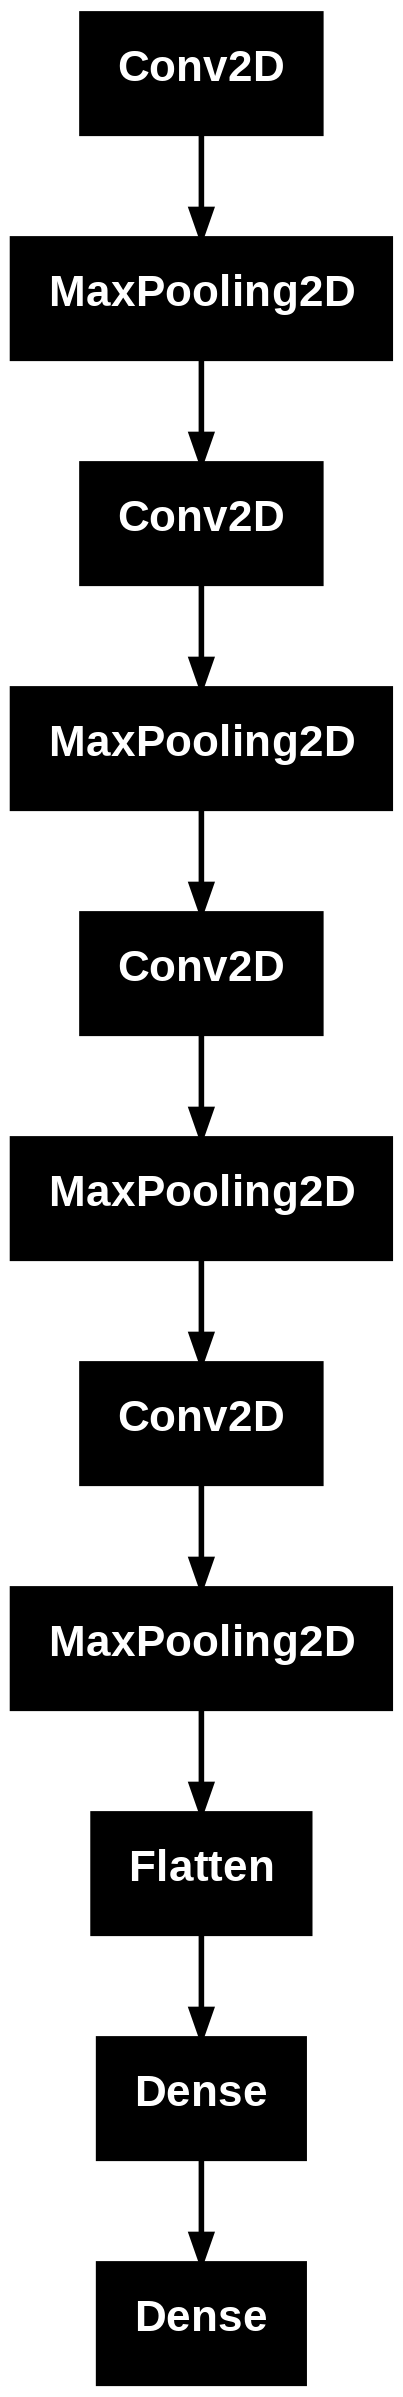

In [ ]:
tf.keras.utils.plot_model(model)

In [ ]:
import matplotlib.pyplot as plt

def plot_learning_curve(history):

  plt.plot(list(range(len(history['loss']))), history['loss'], label='loss')
  plt.plot(list(range(len(history['val_loss']))), history['val_loss'], label='val_loss')
  plt.plot(list(range(len(history['accuracy']))), history['accuracy'], label='accuracy', c='r')
  plt.xlabel('Epochs')
  plt.ylabel("Loss")
  plt.title("Learning Curve avec MSE")
  plt.legend()
  plt.grid()
  plt.show()

def plot_accuracy_curve(history):

  plt.plot(list(range(len(history['accuracy']))), history['accuracy'], label = "accuracy")
  plt.plot(list(range(len(history['val_accuracy']))), history['val_accuracy'], label="val_accuracy")
  plt.xlabel('Epochs')
  plt.ylabel("accuracy")
  plt.title("Accuracy Curve")
  plt.legend(loc='upper left')
  plt.show()

plot_learning_curve(h.history)
plot_accuracy_curve(history)

model_save = tf.keras.models.load_model('best_model.h5')
model_save.evaluate(a_test_images, test_labels)

In [ ]:
plot_learning_curve(h.history)
plot_accuracy_curve(history)
print(f"The best validation accuracy achieved was: {max(h.history['val_accuracy']):.4f} at epoch {h.history['val_accuracy'].index(best_val_accuracy) + 1}")

In [ ]:
# Nombre d'itérations = Nombres de train / nombre batch_size=32 (Du ImageDataGenerator)
22564/32

705.125

In [ ]:
# model_save = tf.keras.models.load_model('best_model.h5')
# model_save.evaluate(train_generator, test_generator)

## Data Augmentation

In [ ]:
# avant augmentation
train_data_generator = ImageDataGenerator(rescale=1/255.0)
test_data_generator = ImageDataGenerator(rescale=1/255.0)


# après augmentation
train_data_generator = ImageDataGenerator(rescale=1/255.0,
                                          rotation_range=40,
                                          width_shift_range=0.2,
                                          height_shift_range=0.2,
                                          shear_range=0.2,
                                          zoom_range=0.2,
                                          horizontal_flip=True,
                                          fill_mode="nearest")
test_data_generator = ImageDataGenerator(rescale=1/255.0)


In [ ]:
train_generator = train_data_generator.flow_from_directory(
    directory = train_dir,
    target_size = (224, 224),
    batch_size=32,
    class_mode="binary"

)


test_generator = test_data_generator.flow_from_directory(
    directory = test_dir,
    target_size = (224, 224),
    batch_size=32,
    class_mode="binary"

)


Found 22564 images belonging to 2 classes.
Found 2513 images belonging to 2 classes.


In [ ]:
model = tf.keras.models.Sequential([

    #Extraction de caractéristiques
    tf.keras.layers.Conv2D(filters=32, kernel_size=(3, 3), padding="same", activation='relu', input_shape=(224, 224,3)),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(filters=64, kernel_size=(3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(filters=128, kernel_size=(3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(filters=128, kernel_size=(3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(2,2),

    # applatir
    tf.keras.layers.Flatten(),

    # Dense
    tf.keras.layers.Dense(units=128, activation="relu"),
    tf.keras.layers.Dense(units=1, activation="sigmoid"),
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model_ckp = tf.keras.callbacks.ModelCheckpoint(filepath="aug_model.h5",
                            monitor="val_accuracy",
                            mode="max",
                            save_best_only=True)
stop = tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=6, restore_best_weights=True)
model.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.001),
              loss="binary_crossentropy",
              metrics=['accuracy'])


In [ ]:
h = model.fit(train_generator, epochs=50,
             validation_data=test_generator,
             callbacks = [model_ckp, stop])


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
706/706 ━━━━━━━━━━━━━━━━━━━━ 0s 410ms/step - accuracy: 0.7442 - loss: 0.5320

706/706 ━━━━━━━━━━━━━━━━━━━━ 296s 416ms/step - accuracy: 0.7443 - loss: 0.5319 - val_accuracy: 0.8074 - val_loss: 0.3958
Epoch 2/50
706/706 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step - accuracy: 0.8226 - loss: 0.4114

706/706 ━━━━━━━━━━━━━━━━━━━━ 295s 418ms/step - accuracy: 0.8226 - loss: 0.4114 - val_accuracy: 0.8826 - val_loss: 0.2905
Epoch 3/50
706/706 ━━━━━━━━━━━━━━━━━━━━ 299s 423ms/step - accuracy: 0.8362 - loss: 0.3869 - val_accuracy: 0.8758 - val_loss: 0.3084
Epoch 4/50
706/706 ━━━━━━━━━━━━━━━━━━━━ 290s 410ms/step - accuracy: 0.8349 - loss: 0.3829 - val_accuracy: 0.8695 - val_loss: 0.3367
Epoch 5/50
706/706 ━━━━━━━━━━━━━━━━━━━━ 288s 407ms/step - accuracy: 0.8431 - loss: 0.3658 - val_accuracy: 0.8575 - val_loss: 0.3758
Epoch 6/50
294/706 ━━━━━━━━━━━━━━━━━━━━ 2:48 408ms/step - accuracy: 0.8515 - loss: 0.3624

In [ ]:
# loss: 0.2942 - accuracy: 0.8854 - val_loss: 0.2266 - val_accuracy: 0.9180
# loss: 0.3518 - accuracy: 0.8522 - val_loss: 0.2764 - val_accuracy: 0.8957


In [ ]:
plot_learning_curve(h.history)
plot_accuracy_curve(history)
print(f"The best validation accuracy achieved was: {max(h.history['val_accuracy']):.4f} at epoch {h.history['val_accuracy'].index(best_val_accuracy) + 1}")

## Transfert Learning


In [ ]:
model.summary()


## Extraction de caractéristiques

In [ ]:
from tensorflow.keras.applications import vgg16


In [ ]:
pretrained_model = vgg16.VGG16(include_top=True, weights='imagenet', input_shape=(224, 224, 3))


In [ ]:
pretrained_model.summary()


In [ ]:
pretrained_model = vgg16.VGG16(include_top=False, weights='imagenet', input_shape=(224, 224, 3))


In [ ]:
pretrained_model.summary()


In [ ]:
(32, 224, 224, 3) ==> (32, 7, 7, 512)


### API Sequential

In [ ]:
model = tf.keras.models.Sequential([

    #Extraction de caractéristiques
    tf.keras.layers.Conv2D(filters=32, kernel_size=(3, 3), padding="same", activation='relu', input_shape=(224, 224,3)),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(filters=64, kernel_size=(3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(filters=128, kernel_size=(3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(filters=128, kernel_size=(3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(2,2),

    # applatir
    tf.keras.layers.Flatten(),

    # Dense
    tf.keras.layers.Dense(units=128, activation="relu"),
    tf.keras.layers.Dense(units=1, activation="sigmoid"),
                ])


In [ ]:
model = tf.keras.models.Sequential()


In [ ]:
model.add(tf.keras.layers.Conv2D(filters=32, kernel_size=(3, 3), padding="same", activation='relu', input_shape=(224, 224,3)))


In [ ]:
model.summary()


In [ ]:
model.add(tf.keras.layers.MaxPooling2D(2,2))


In [ ]:
model.summary()


### Api functional

In [ ]:
inputs = tf.keras.Input(shape=(224, 224, 3))
x =  tf.keras.layers.Conv2D(filters=32, kernel_size=(3, 3))(inputs)
x = tf.keras.layers.MaxPooling2D(2,2)(x)
outputs = tf.keras.layers.Flatten()(x)


In [ ]:
model = tf.keras.Model(inputs, outputs)


### Utilisation des filtres de VGG 16

In [ ]:
pretrained_model.trainable = False


In [ ]:
flatten_layer = tf.keras.layers.Flatten()


In [ ]:
inputs = tf.keras.Input(shape=(224, 224, 3))
x = pretrained_model(inputs, training=False)
x = flatten_layer(x) # 7*7*512
x = tf.keras.layers.Dense(128, activation='relu')(x)
outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)


model = tf.keras.Model(inputs, outputs)


In [ ]:
model.summary()


In [ ]:
model_ckp = tf.keras.callbacks.ModelCheckpoint(filepath="aug_model.h5",
                            monitor="val_accuracy",
                            mode="max",
                            save_best_only=True)
stop = tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=6, restore_best_weights=True)
model.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.001),
              loss="binary_crossentropy",
              metrics=['accuracy'])


In [ ]:
h = model.fit(train_generator, epochs=50,
             validation_data=test_generator,
             callbacks = [model_ckp, stop])


In [ ]:
# loss: 0.2942 - accuracy: 0.8854 - val_loss: 0.2266 - val_accuracy: 0.9180
# loss: 0.3518 - accuracy: 0.8522 - val_loss: 0.2764 - val_accuracy: 0.8957
# loss: 0.2165 - accuracy: 0.9160 - val_loss: 0.3172 - val_accuracy: 0.8926


In [ ]:
plot_learning_curve(h.history)
plot_accuracy_curve(history)
print(f"The best validation accuracy achieved was: {max(h.history['val_accuracy']):.4f} at epoch {h.history['val_accuracy'].index(best_val_accuracy) + 1}")

## Fine Tuning

In [ ]:
pretrained_model.summary()


In [ ]:
pretrained_model.layers


In [ ]:
pretrained_model.trainable=True


In [ ]:
pretrained_model.layers[:-4]


In [ ]:
for layer in pretrained_model.layers[:-4]:
  layer.trainable = False


In [ ]:
inputs = tf.keras.Input(shape=(224, 224, 3))
x = pretrained_model(inputs, training=False)
x = flatten_layer(x) # 7*7*512
x = tf.keras.layers.Dense(128, activation='relu')(x)
outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)


model = tf.keras.Model(inputs, outputs)


In [ ]:
model.summary()


In [ ]:
model_ckp = tf.keras.callbacks.ModelCheckpoint(filepath="aug_model.h5",
                            monitor="val_accuracy",
                            mode="max",
                            save_best_only=True)
stop = tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=2, restore_best_weights=True)
model.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.001),
              loss="binary_crossentropy",
              metrics=['accuracy'])


In [ ]:
h = model.fit(train_generator, epochs=50,
             validation_data=test_generator,
             callbacks = [model_ckp, stop])


In [ ]:
plot_learning_curve(h.history)
plot_accuracy_curve(history)
print(f"The best validation accuracy achieved was: {max(h.history['val_accuracy']):.4f} at epoch {h.history['val_accuracy'].index(best_val_accuracy) + 1}")